In [1]:
import sys
import os
import torch
import torch.nn as nn

sys.path.append(os.path.abspath(".."))
from seismic_facies.procs import dataset, helper, tf, dataloader
from seismic_facies.viz import viz_dataset
from seismic_facies.models import loss
from seismic_facies.models.unet import model as unet_model
from seismic_facies.models.unet import utils as unet_utils

In [2]:
helper.set_seed(42)
device = helper.select_device()

No GPU available!


In [3]:
data_path = 'train/train_seismic.npy'
label_path = 'train/train_labels.npy'

In [4]:
transformation = tf.JointCompose([
    tf.RandomRotate(5),
    #tf.RandomHorizontalFlip(p=0.5),
    tf.GaussianBlurXOnly(kernel_size=3, p=0.3),
    tf.AddNoiseXOnly(std=0.01, p=0.5),
])

base_dataset = dataset.SeismicSliceDataset(seismic_path=data_path, labels_path=label_path, transform=transformation, mode="both")
base_dataset

i


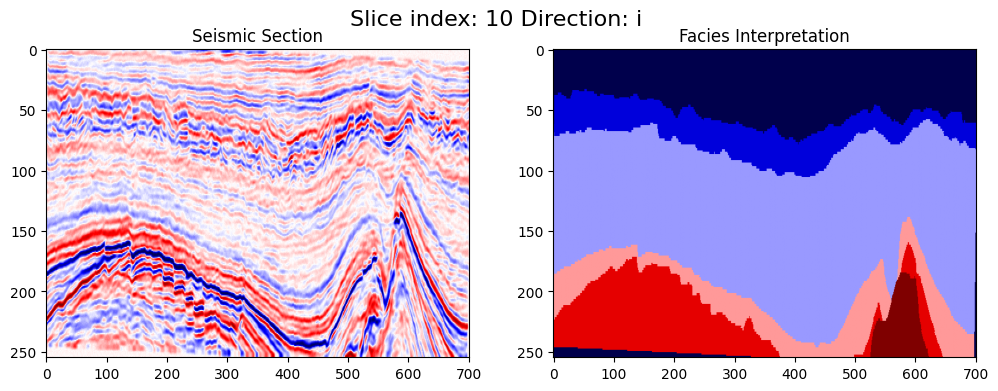

In [5]:
viz_dataset.viz_dataset_by_idx(base_dataset, idx=10)

In [6]:
train_ds, val_ds = dataset.create_train_val_datasets(base_dataset, val_frac=0.2, seed=42)
train_ds, val_ds

(<torch.utils.data.dataset.Subset at 0x7c6b6ce1e900>,
 <torch.utils.data.dataset.Subset at 0x7c6b6cec9450>)

i


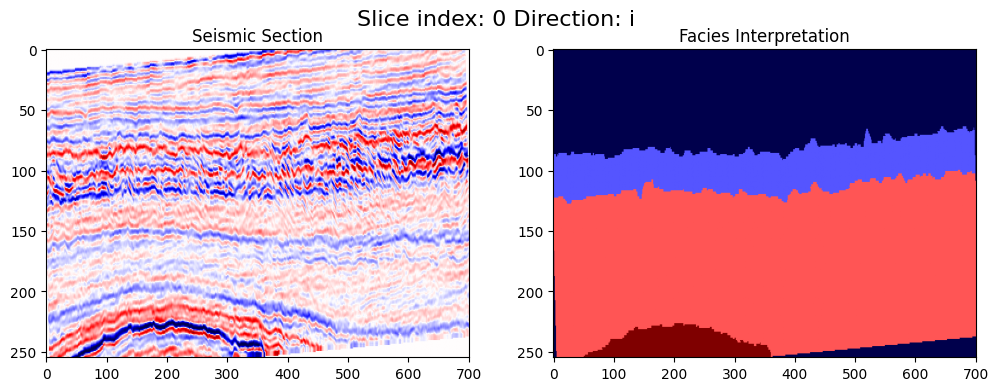

In [7]:
viz_dataset.viz_dataset_by_idx(train_ds, idx=0)

In [8]:
batch_size= 12 

train_loader = dataloader.create_dataloader_with_direction_batches(train_ds, batch_size)
val_loader   = dataloader.create_dataloader_with_direction_batches(val_ds, batch_size)

train_loader, val_loader

(<torch.utils.data.dataloader.DataLoader at 0x7c6b6ce1ea50>,
 <torch.utils.data.dataloader.DataLoader at 0x7c6b7c14b890>)

In [9]:
class_weights = helper.compute_class_weights(
    train_ds,
    ignore_index=-1,
    #max_samples=500,    # optional speed-up
)
class_weights

  0%|          | 0/882 [00:00<?, ?it/s]

100%|██████████| 882/882 [00:17<00:00, 50.22it/s]


tensor([0.1516, 0.3779, 0.0933, 0.7090, 1.5058, 3.1624])

In [10]:
unet = unet_model.UNet(in_channels=1, n_classes=6).to(device)
unet

UNet(
  (e1): EncBlock(
    (conv_block1): ConvBlock(
      (c): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): GroupNorm(8, 8, eps=1e-05, affine=True)
      (activation): SiLU()
    )
    (conv_block2): ConvBlock(
      (c): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): GroupNorm(8, 8, eps=1e-05, affine=True)
      (activation): SiLU()
    )
    (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (e2): EncBlock(
    (conv_block1): ConvBlock(
      (c): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): GroupNorm(8, 16, eps=1e-05, affine=True)
      (activation): SiLU()
    )
    (conv_block2): ConvBlock(
      (c): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): GroupNorm(8, 16, eps=1e-05, affine=True)
      (activation): SiLU()
    )
    (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=Fa

In [11]:
lr = 5e-4
nepochs = 30
wd = 5e-4

In [ ]:
optimiser_unet = torch.optim.AdamW(params=unet.parameters(), lr=lr, weight_decay=wd)

unet_utils.training_loop(
    model=unet,
    optimizer=optimiser_unet,
    class_weights=class_weights,
    alpha=0.3,
    train_loader=train_loader,
    valid_loader=val_loader,
    device=device,
    nepochs=nepochs,
)


![U-Net training with CE and Dice loss](../assets/unet_training.png "U-Net Training")
